# Set-up colab


In [ ]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/USA
from fairness_metric_utils import *
from penalty_utils import *

/content/drive/MyDrive/USA


In [ ]:
%cd /content/drive/MyDrive/USA/COMPAS

# Load Data

In [ ]:
dataset_path = 'COMPAS/compas-preprocessed.csv'
df=pd.read_csv(dataset_path)

fair_metrics=[ 'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'] #'PPE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP' #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race']
mapping= {
    'age':{
        0: 'a<25',
        1: '25>a>40',
        2: 'a>45',
    },
    'sex':{
        0: 'fem',
        1: 'mal'
    },
    'race':{
        0: 'African',
        1: 'AsianWhite',
        2: 'HispNatOth'
    }
}
feature_cols= df.columns
target_variable = 'is_violent_recid'
target_variable_labels= ['0','1']
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_violent_recid
0,1,2,2,0,1,0,0,0,0
1,1,2,2,0,1,0,0,0,0
2,1,1,1,0,5,0,0,0,0
3,1,1,0,0,3,0,0,0,1
4,1,0,0,0,4,0,1,4,0


#Compute Fairness

In [ ]:
pairs_dict= {}
fairness_metrics_dict= {}
differences = {}
s= []
for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    fairness_metrics_dict[sensible_attribute], differences[sensible_attribute] = get_attribute_analysis(df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping,target_variable_labels)

['age']
GFA {2: 0.00940733772342427, 1: 0.018639972385226095, 0: 0.046905537459283386}
Max value: 0.047 (Key: 0)
Min value: 0.009 (Key: 2)
Max-min: 0.038
PPA {2: 0.4, 1: 0.5555555555555556, 0: 0.5833333333333334}
Max value: 0.583 (Key: 0)
Min value: 0.4 (Key: 2)
Max-min: 0.183
FPR {2: 0.6, 1: 0.4444444444444444, 0: 0.4166666666666667}
Max value: 0.6 (Key: 2)
Min value: 0.417 (Key: 0)
Max-min: 0.183
PPE {2: 0.005859375, 1: 0.008905380333951763, 0: 0.021246458923512748}
Max value: 0.021 (Key: 0)
Min value: 0.006 (Key: 2)
Max-min: 0.015
FPA {2: 0.03323836657169991, 1: 0.06049947238832219, 0: 0.05536568694463431}
Max value: 0.06 (Key: 1)
Min value: 0.033 (Key: 2)
Max-min: 0.027
OAE {2: 0.9614299153339605, 1: 0.9323438039351053, 0: 0.9276872964169381}
Max value: 0.961 (Key: 2)
Min value: 0.928 (Key: 0)
Max-min: 0.033
EOP {2: 0.8974358974358975, 1: 0.8514851485148515, 0: 0.6585365853658537}
Max value: 0.897 (Key: 2)
Min value: 0.659 (Key: 0)
Max-min: 0.238
FNP {2: 0.03292568203198495, 1: 0.0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# Plot

In [ ]:
df=pd.read_csv(dataset_path)

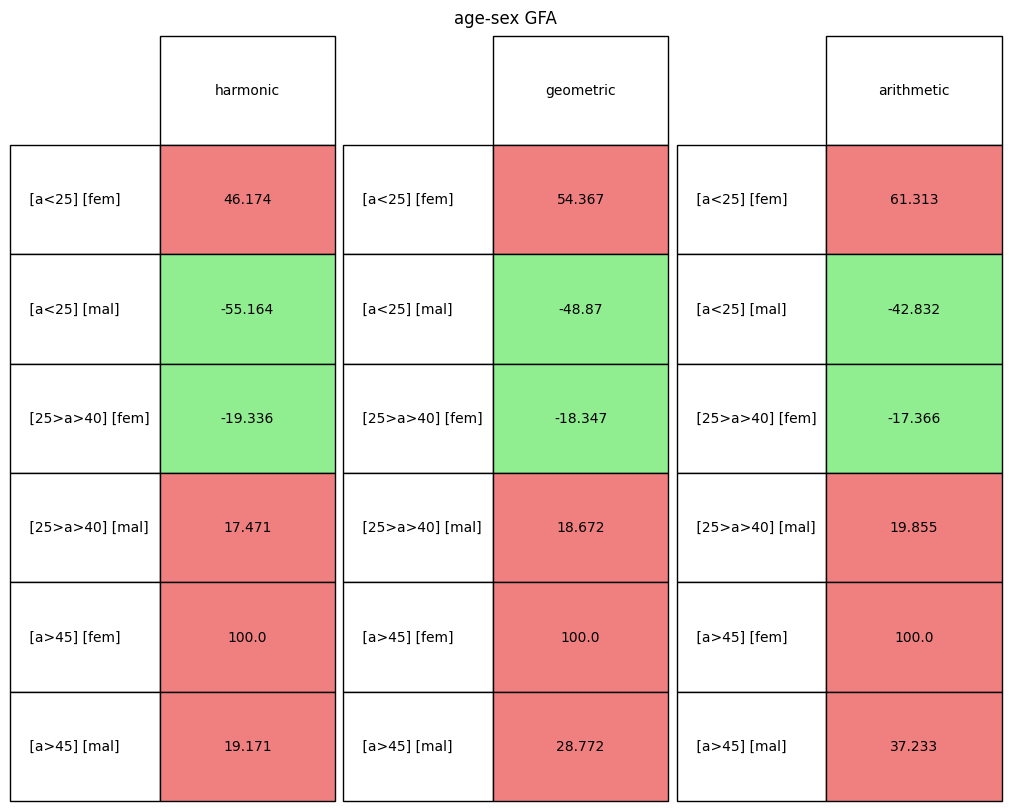

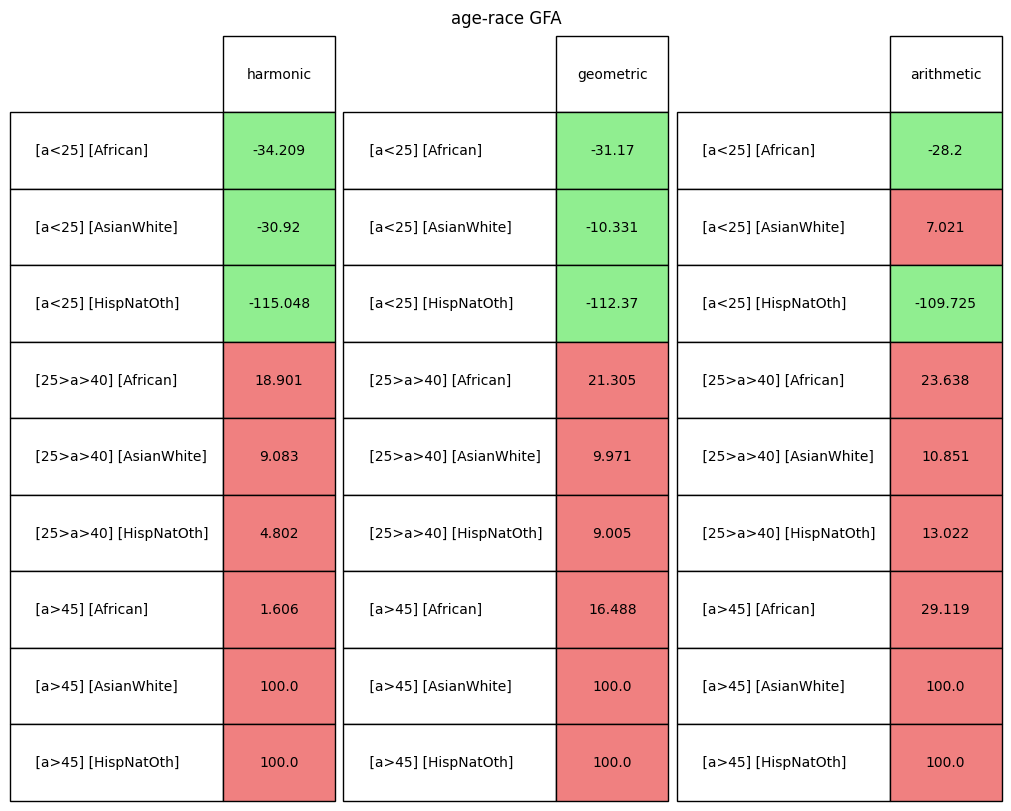

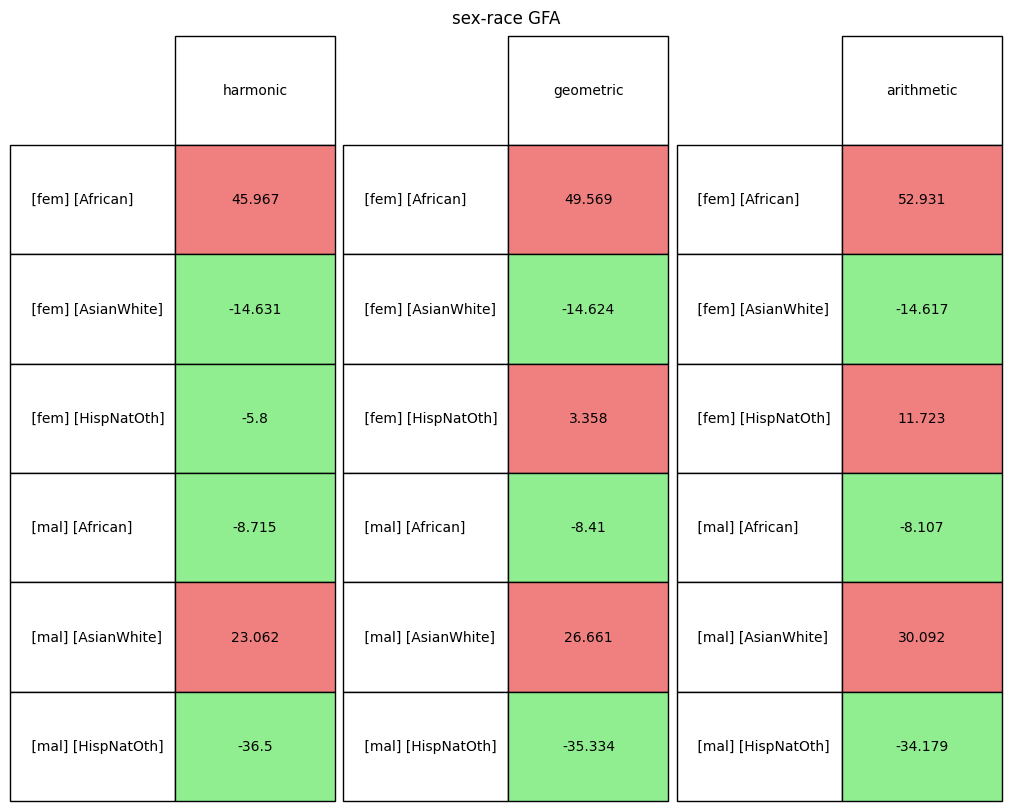

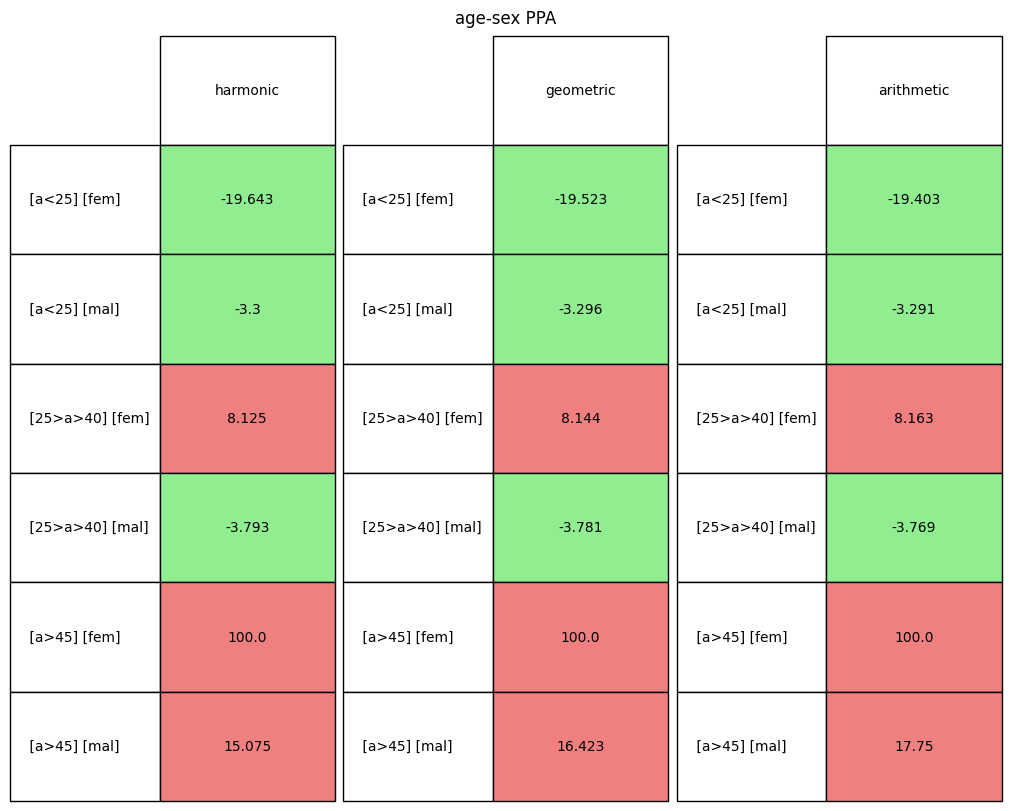

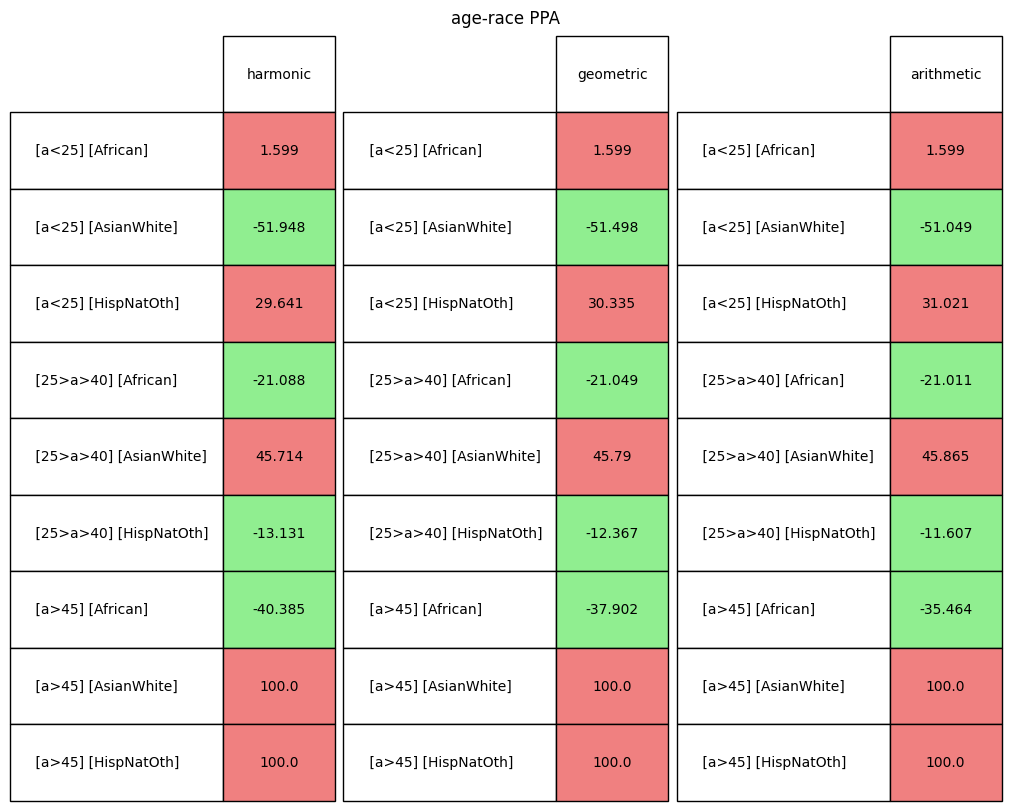

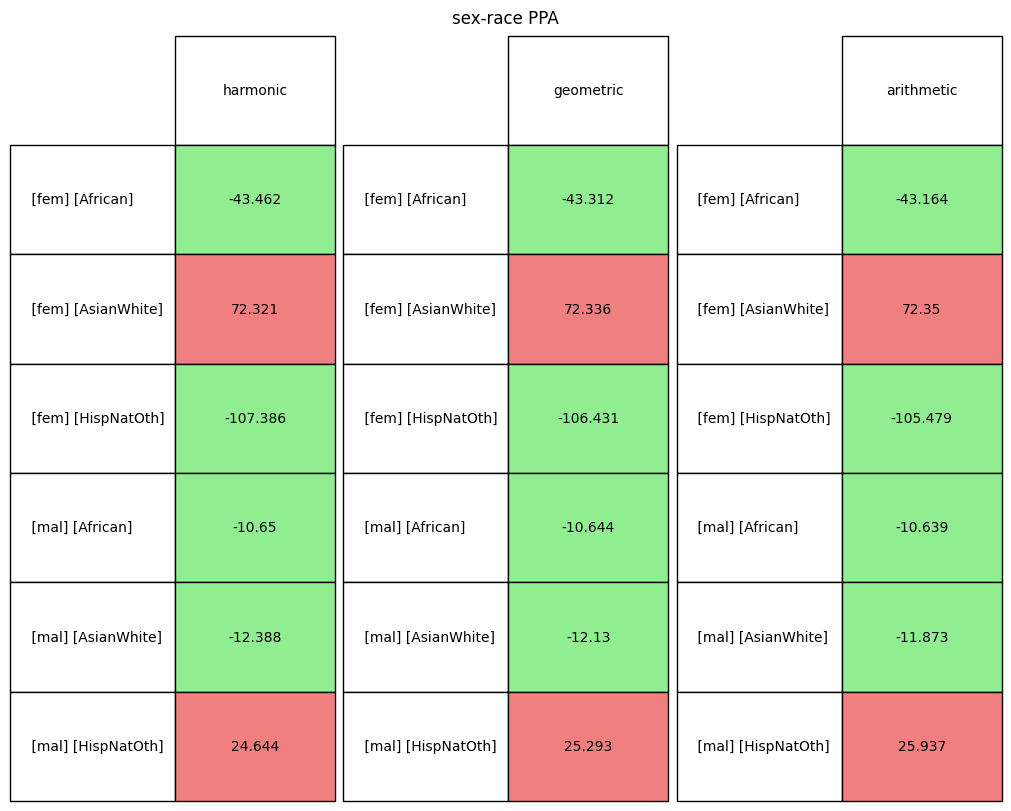

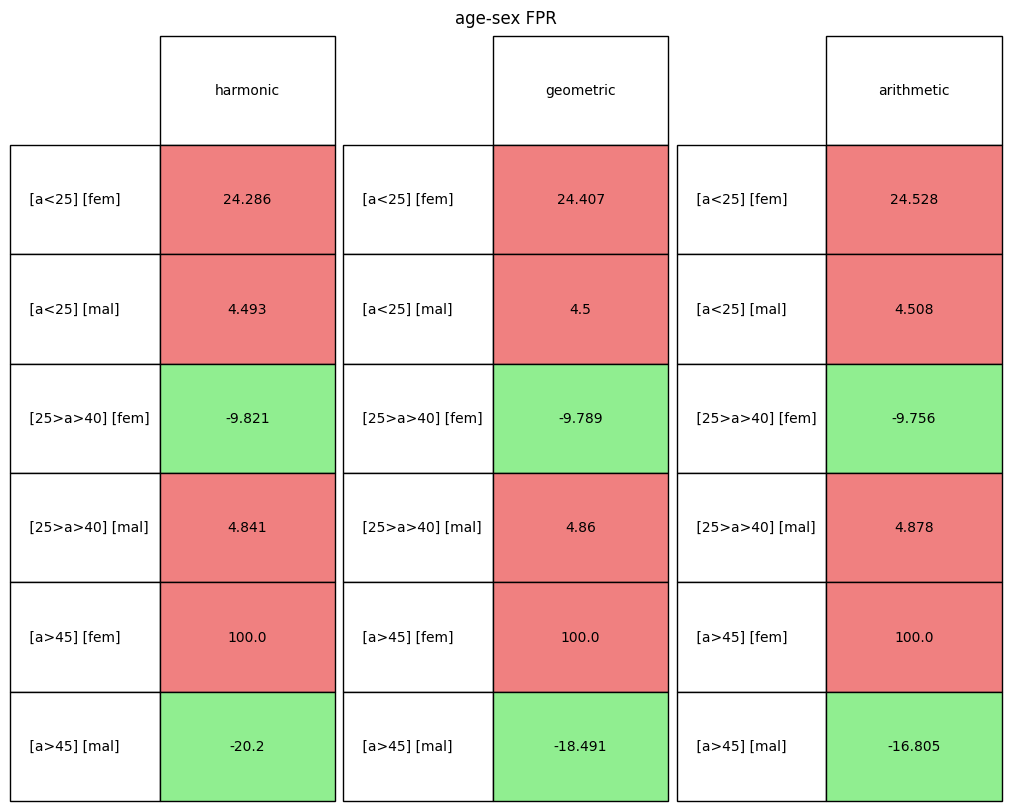

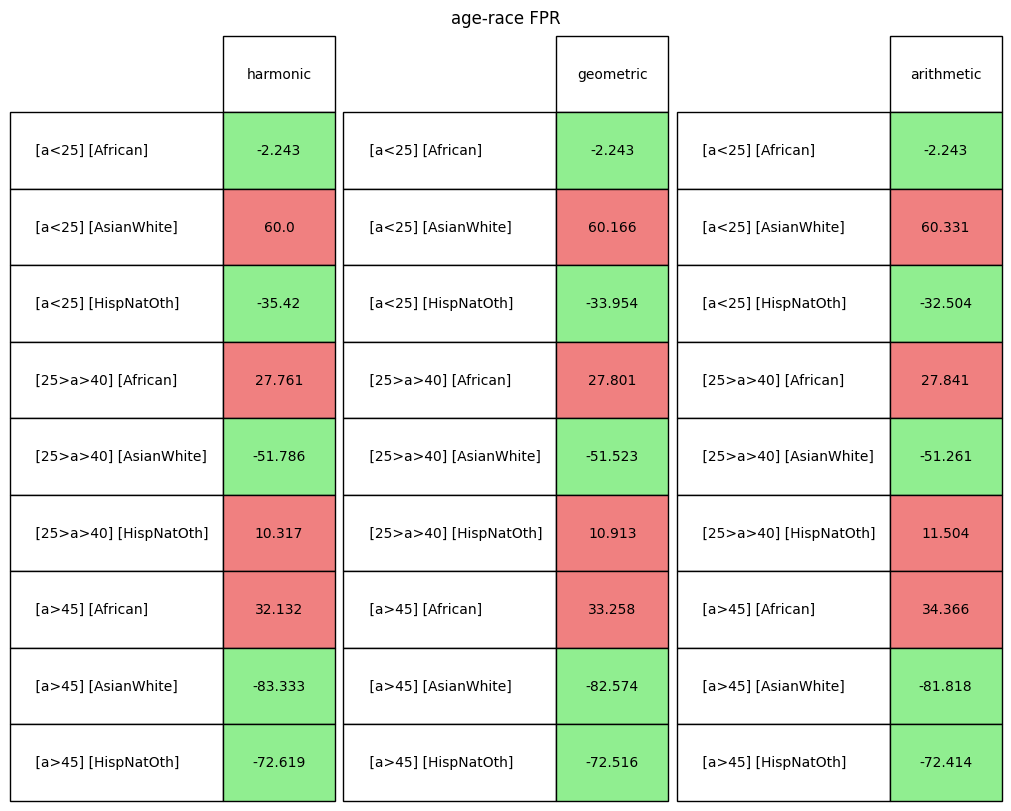

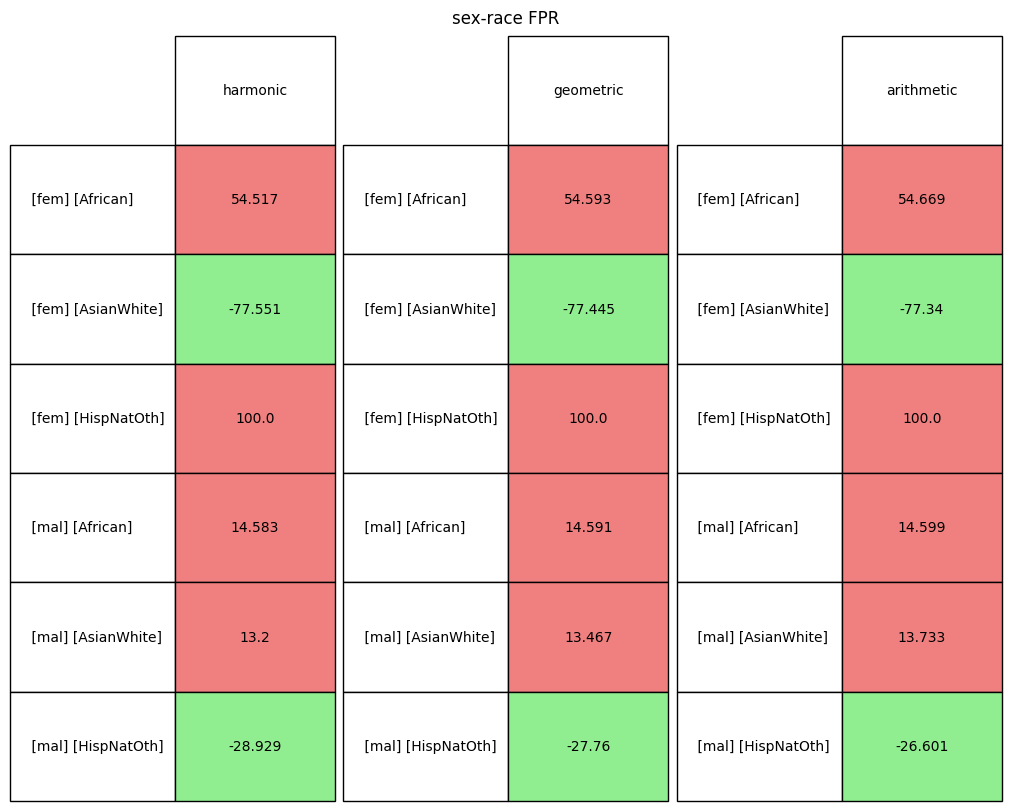

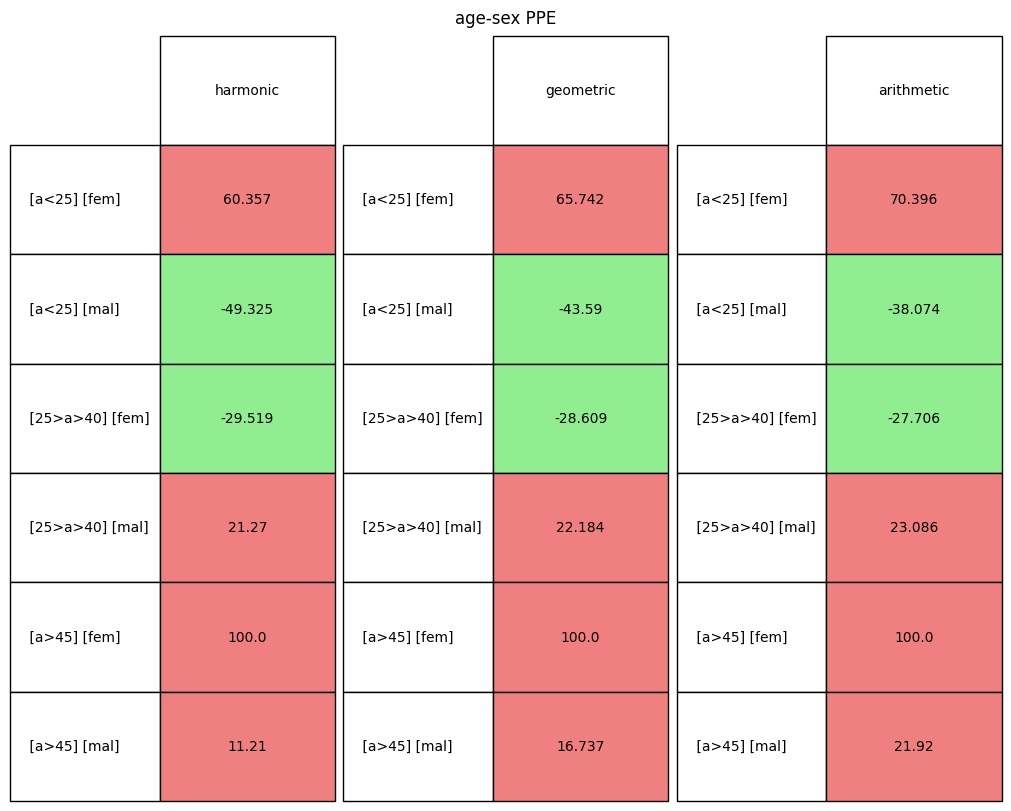

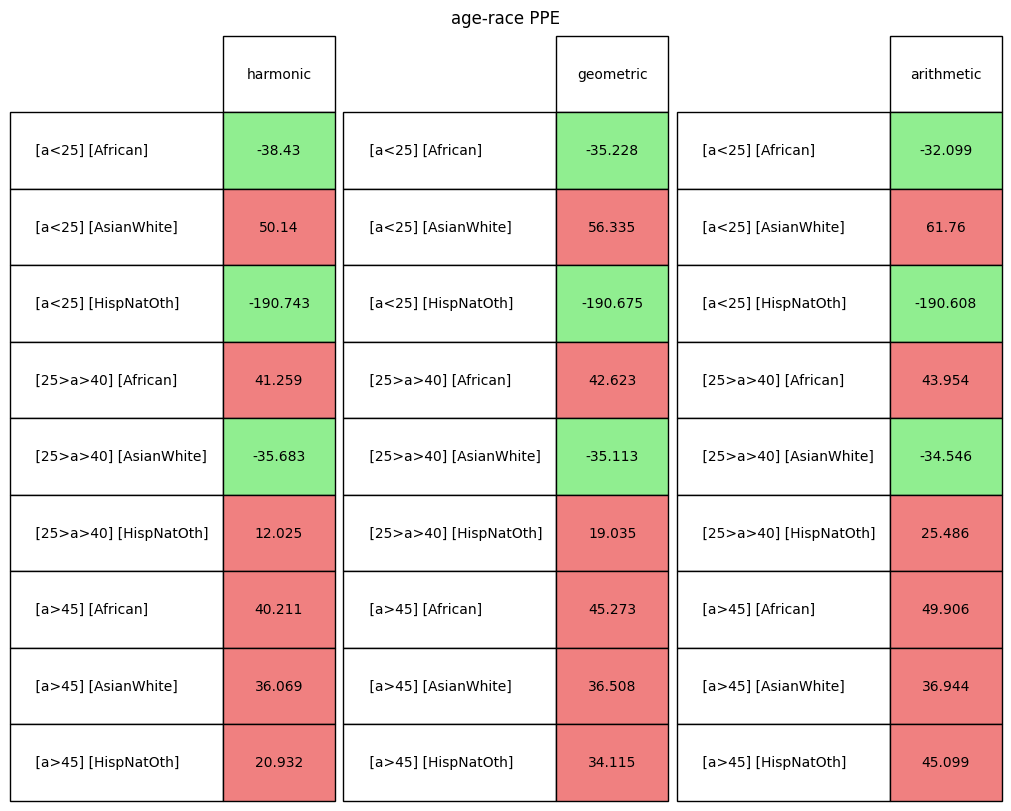

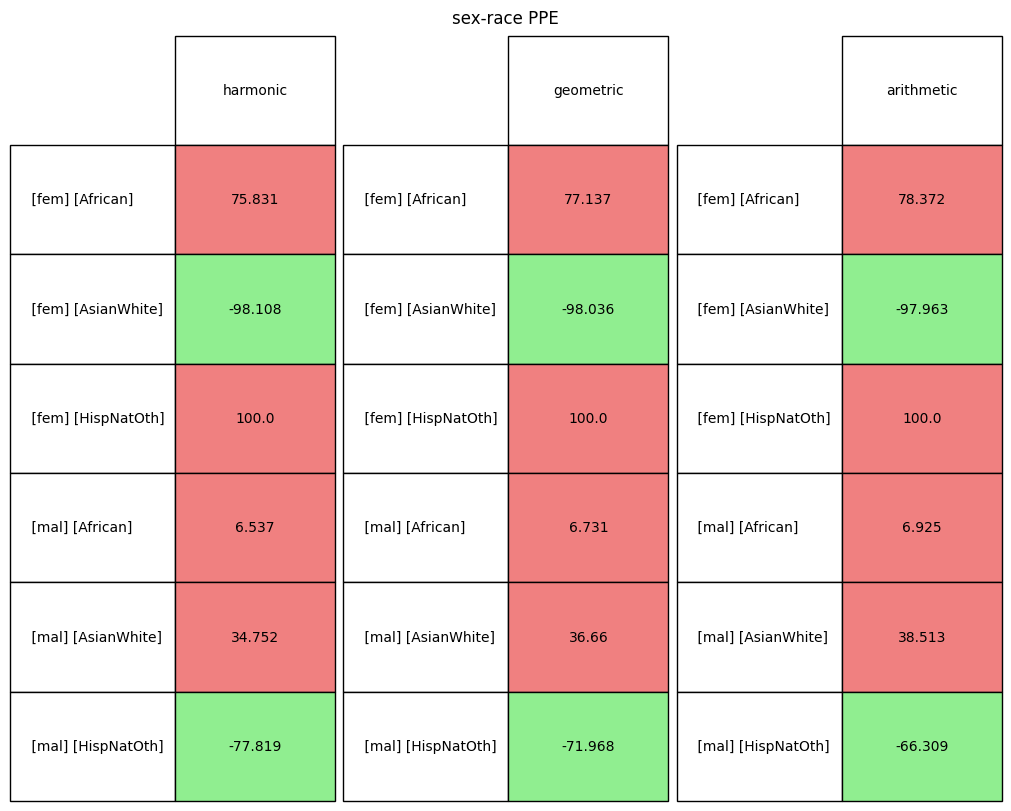

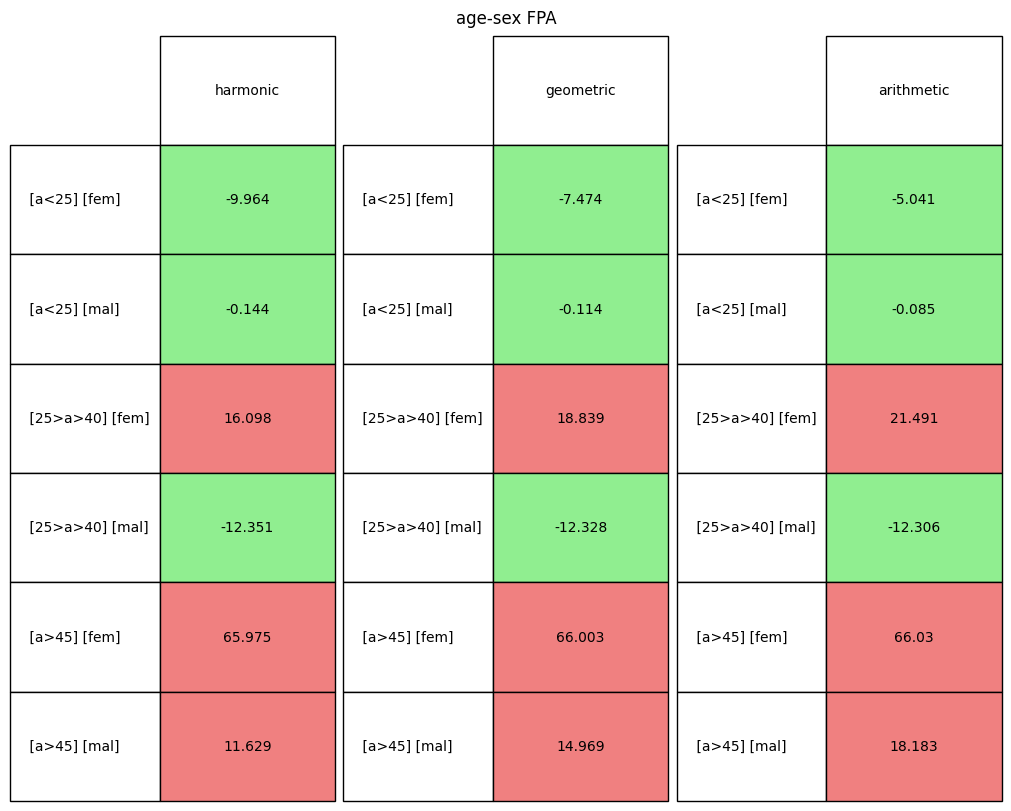

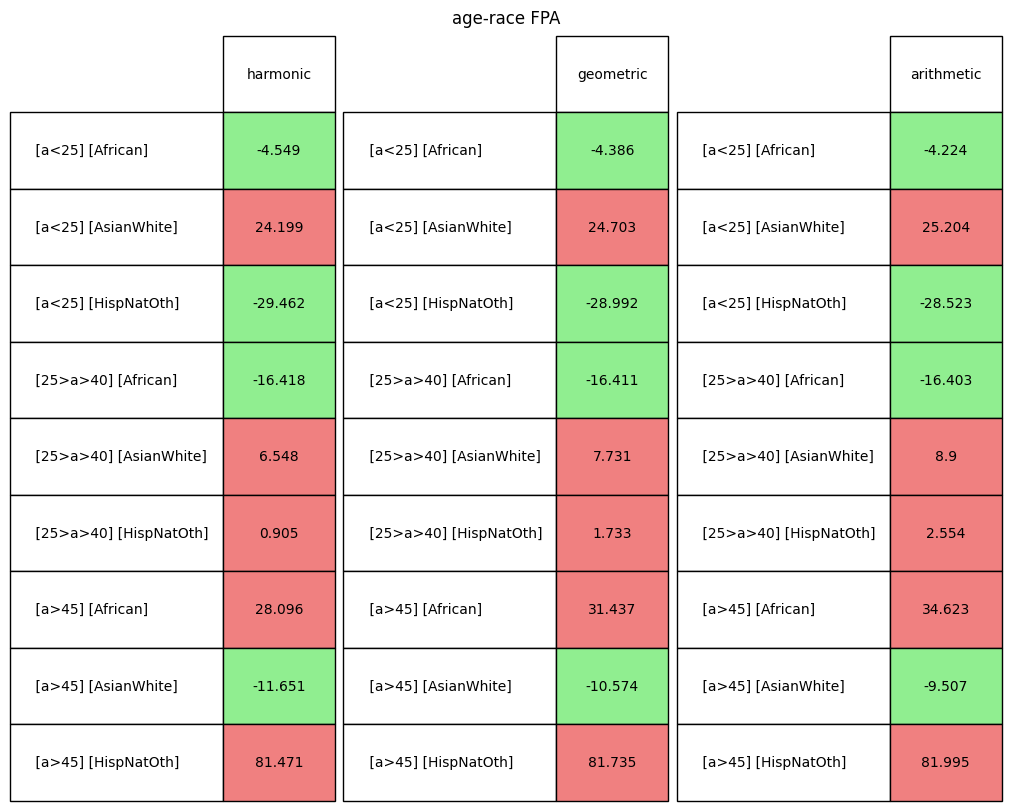

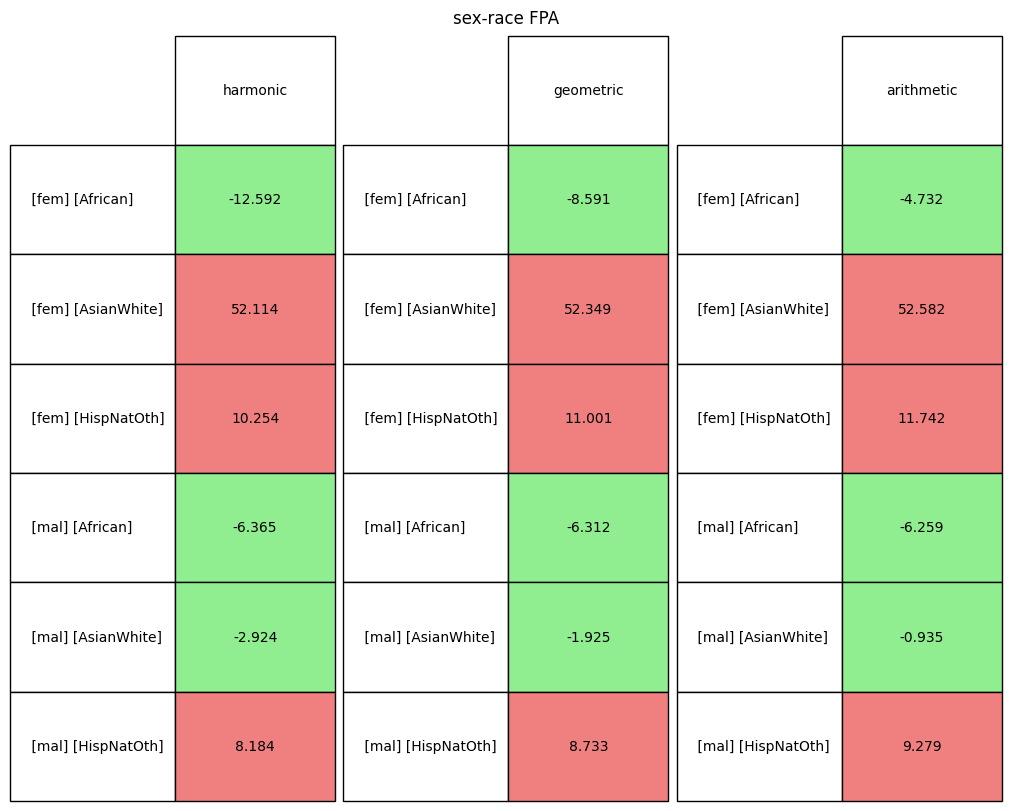

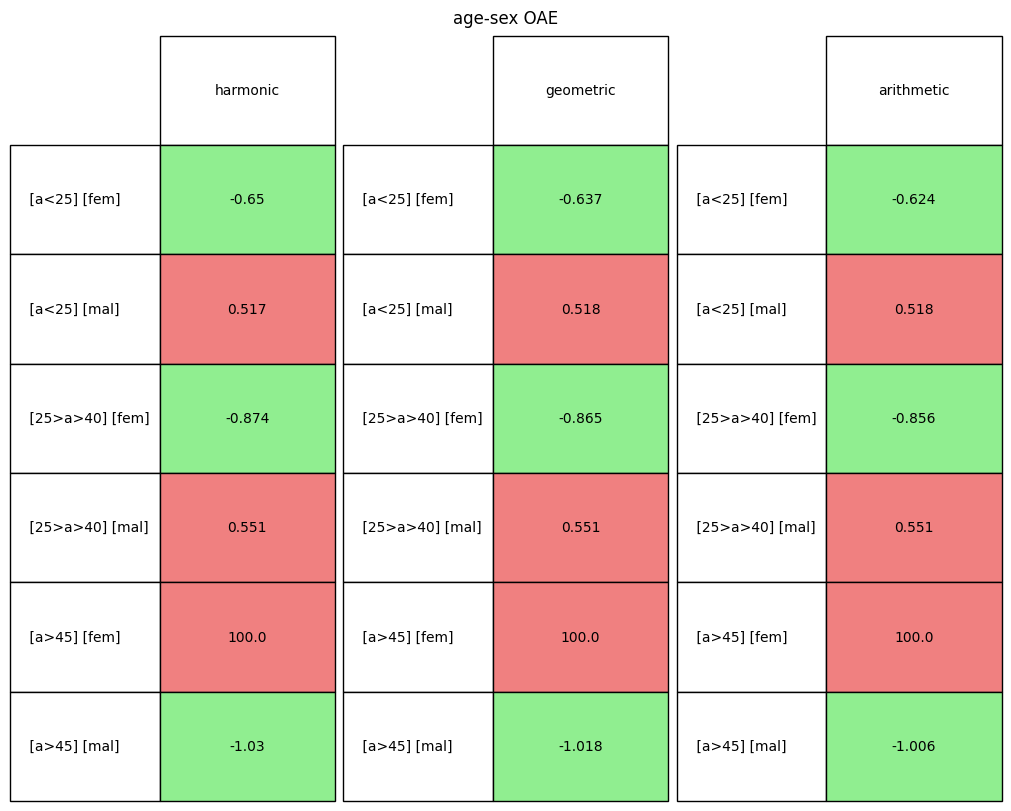

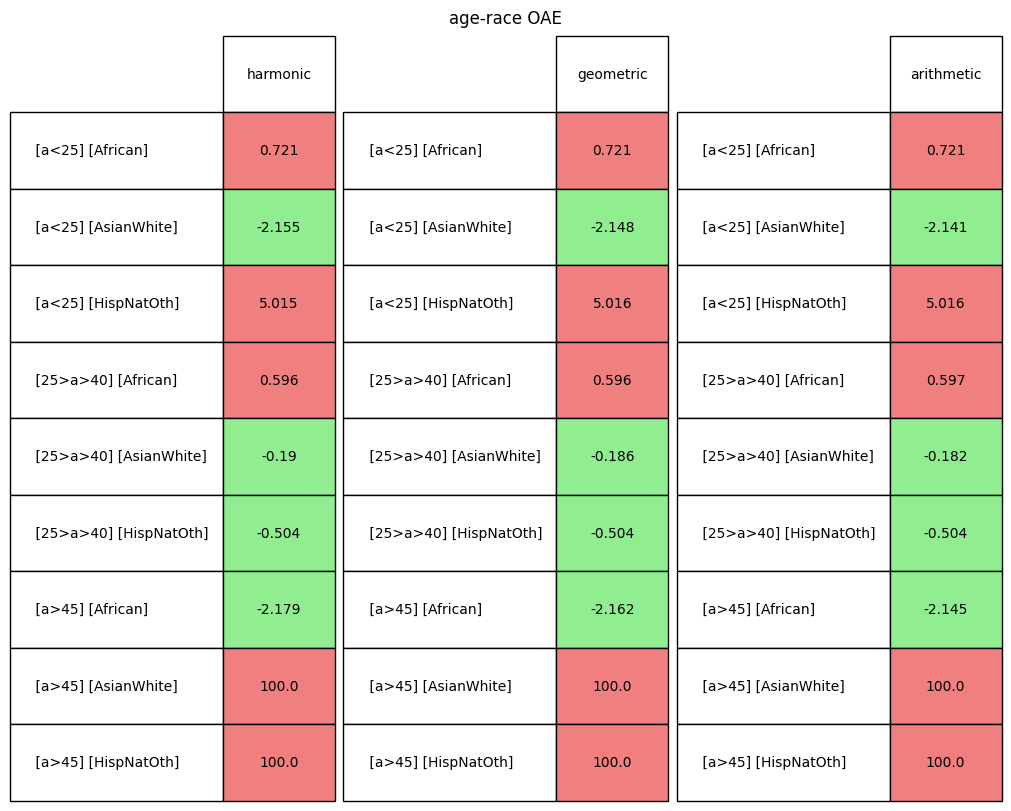

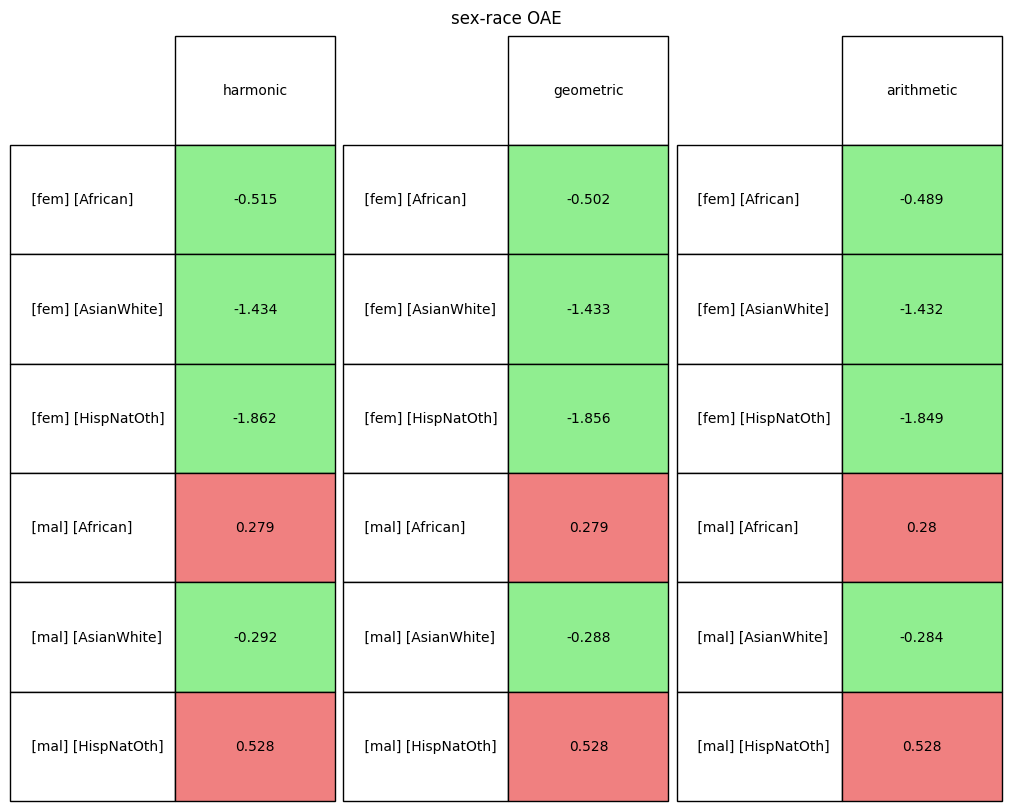

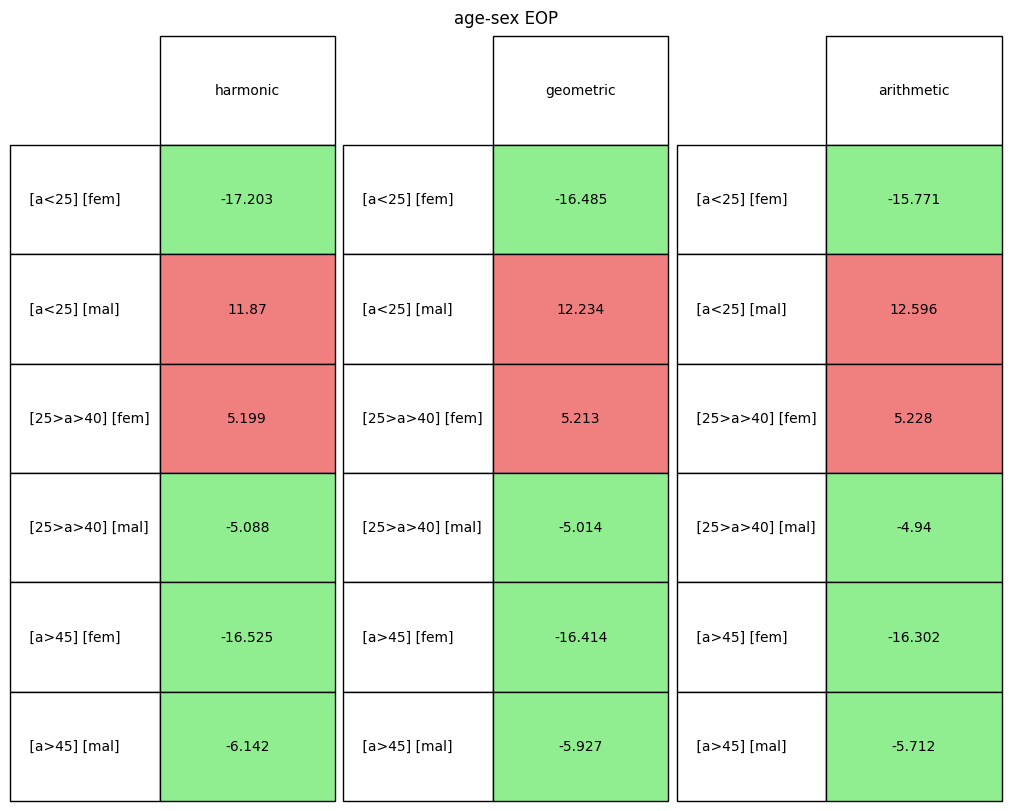

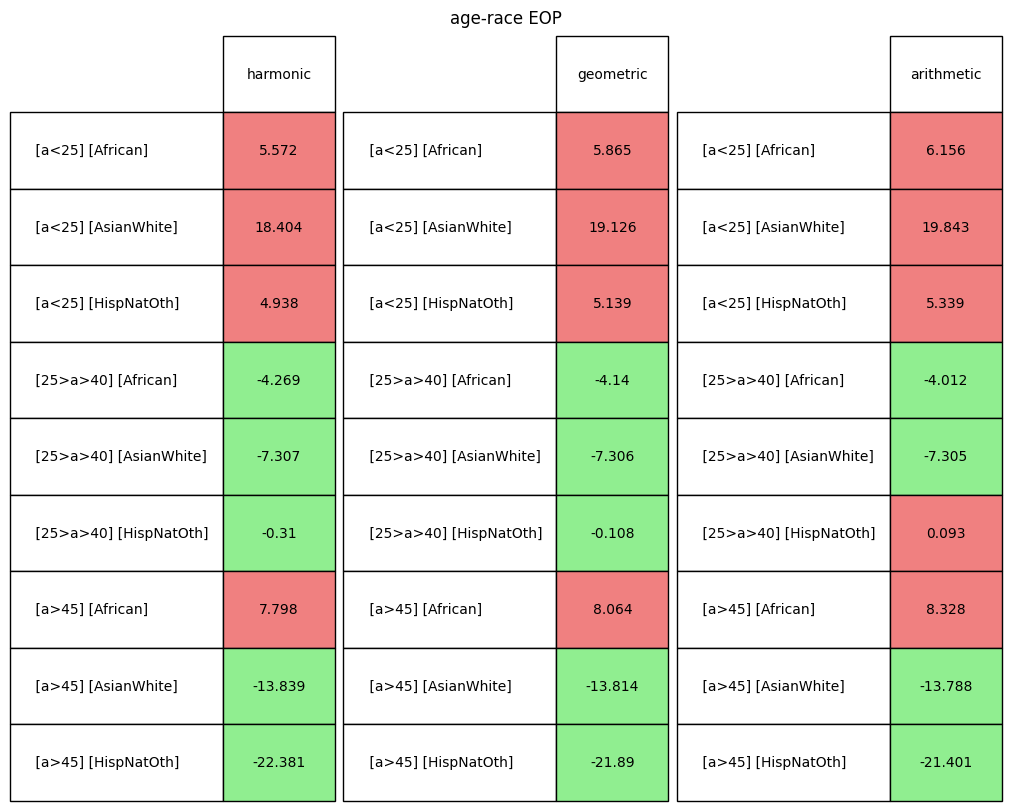

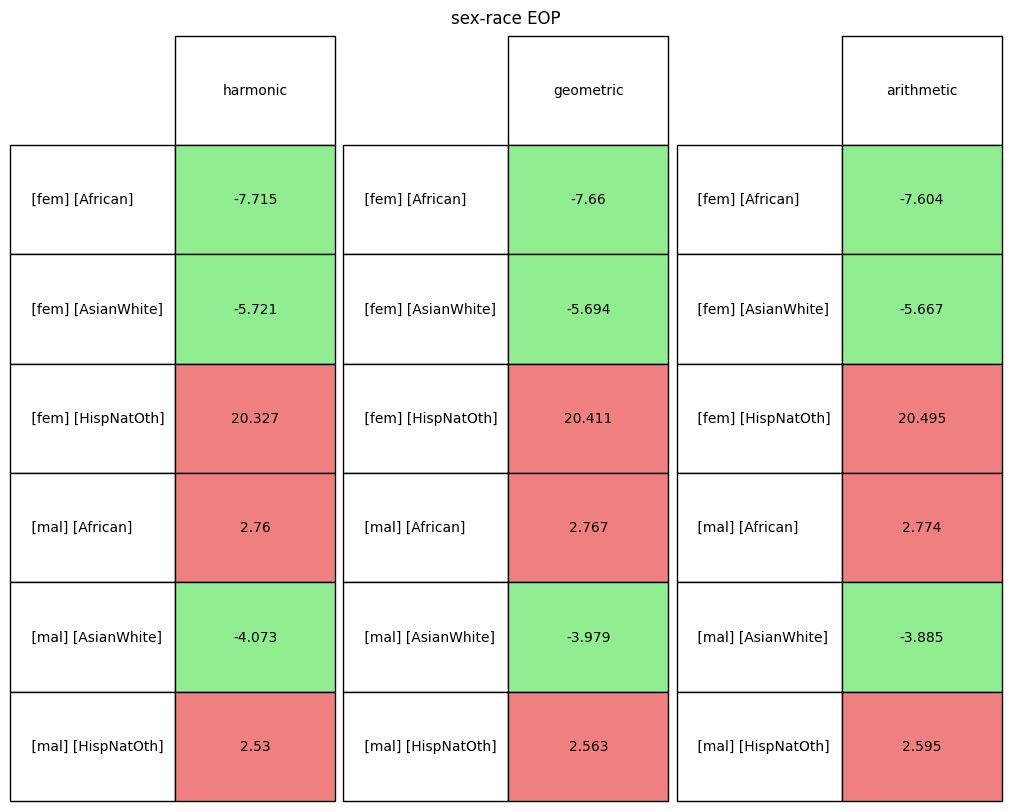

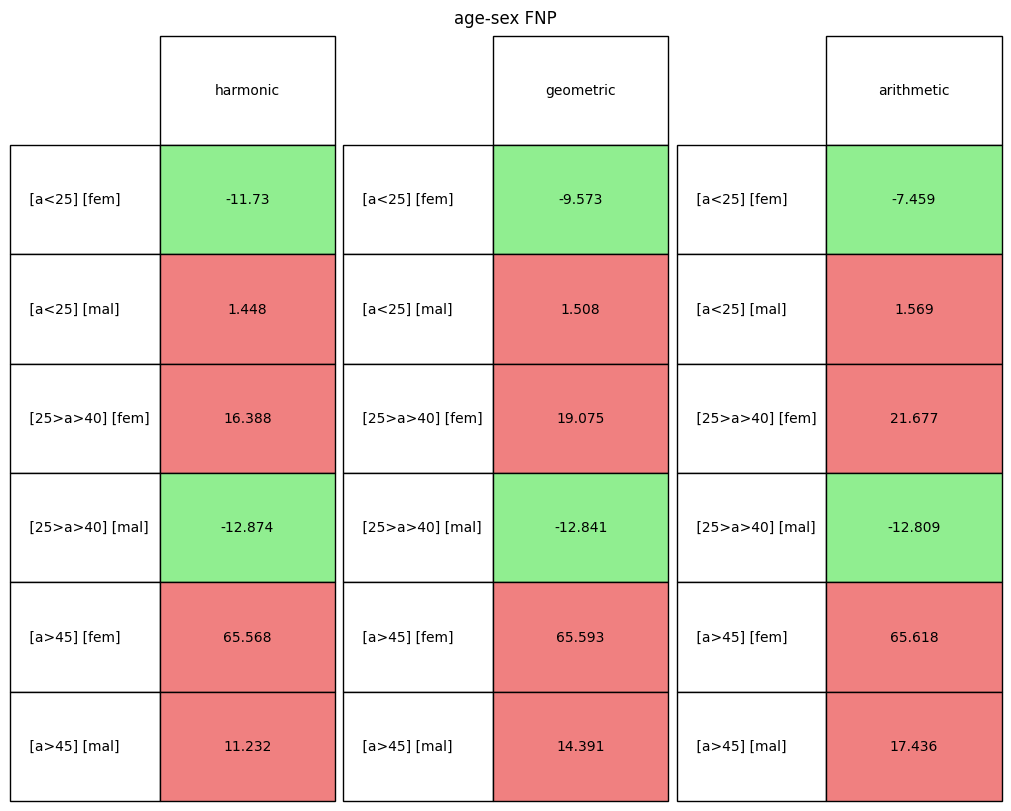

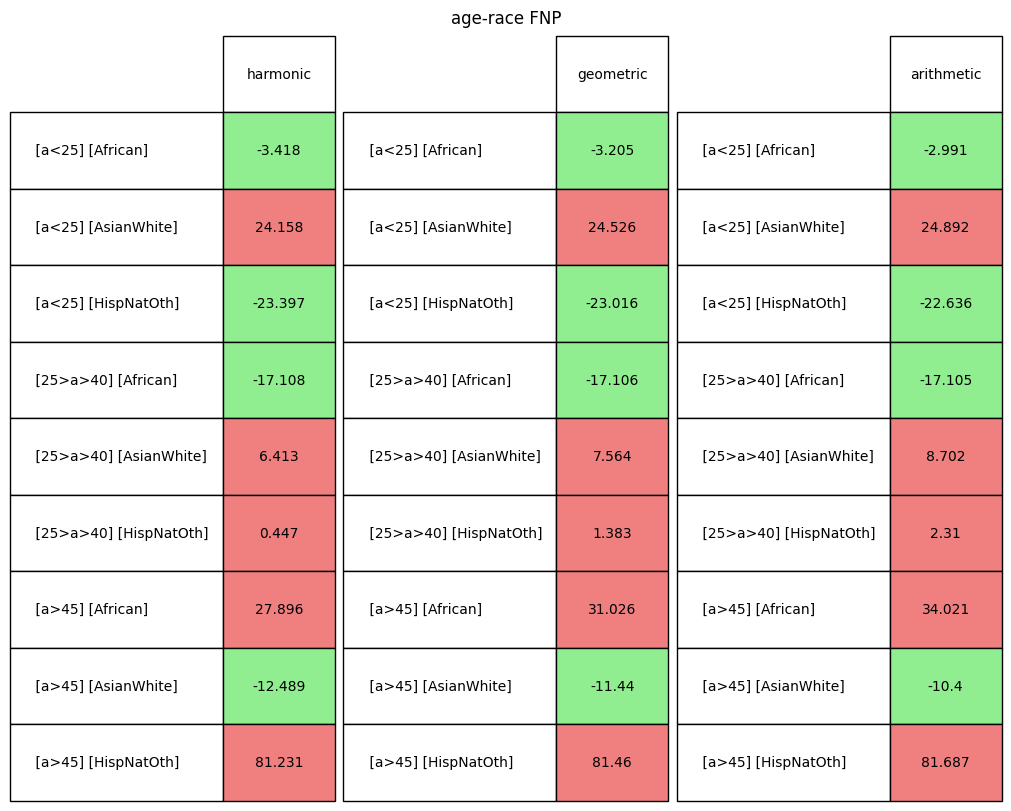

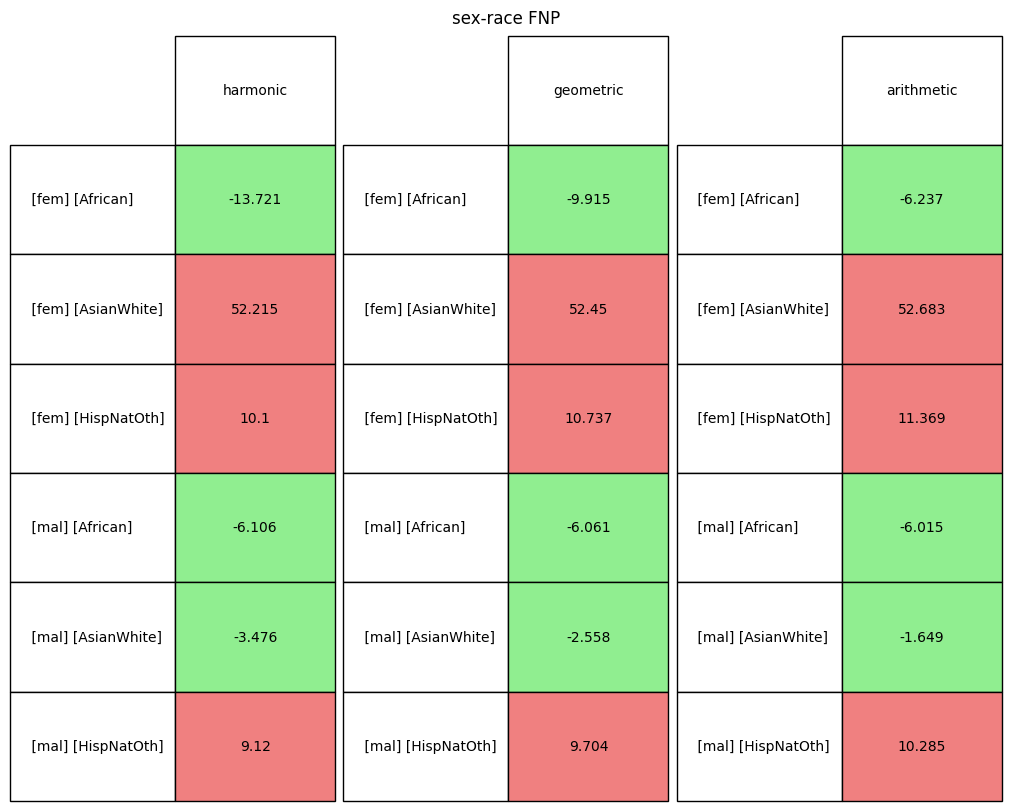

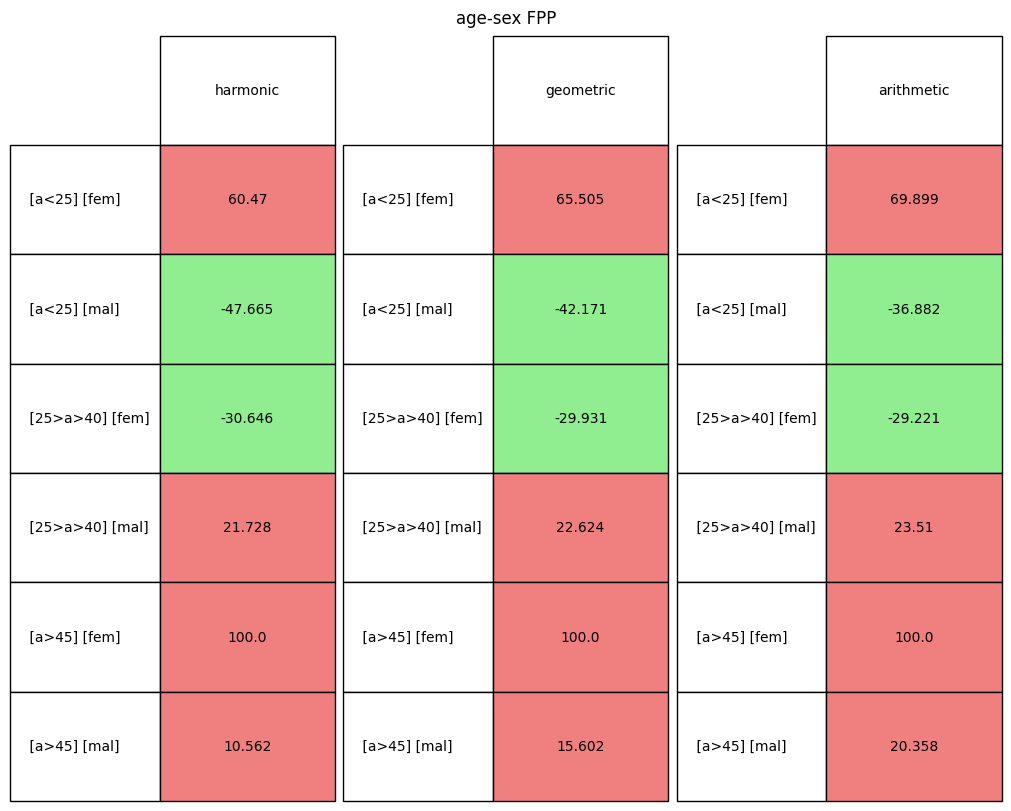

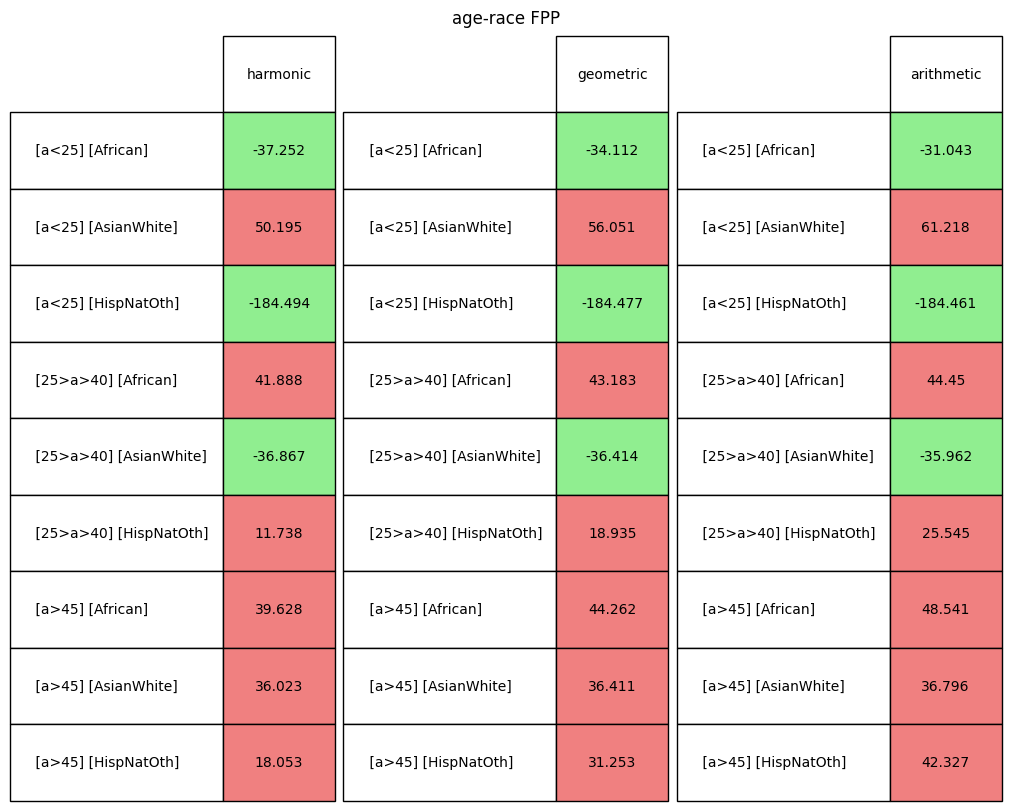

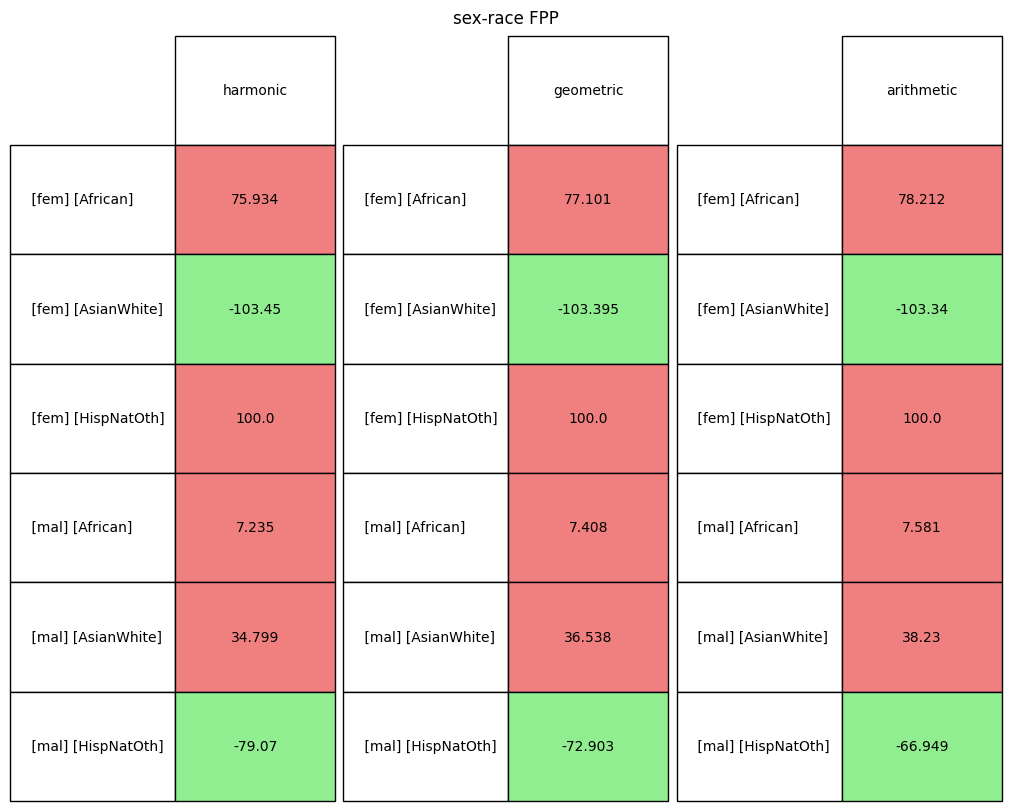

In [ ]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==3:
        #print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

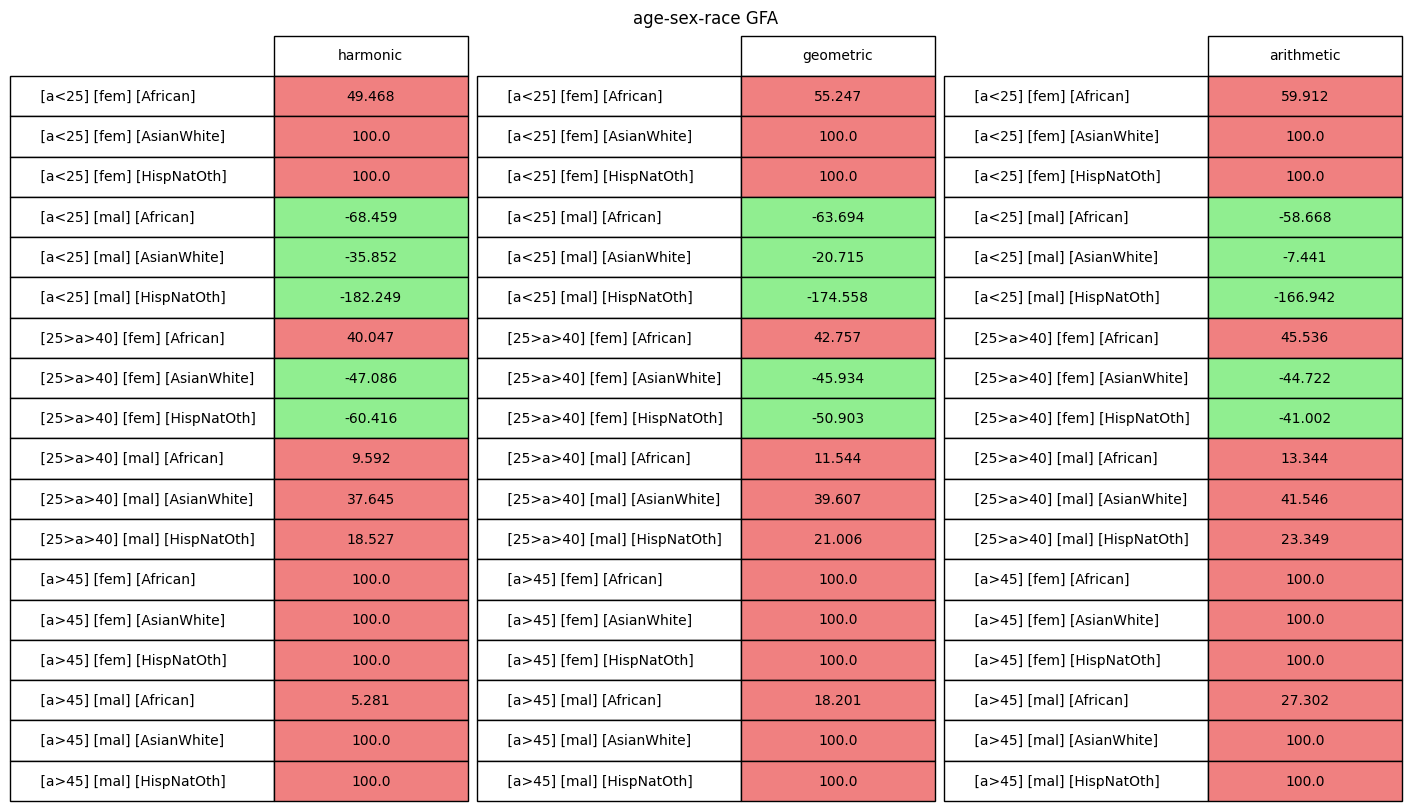

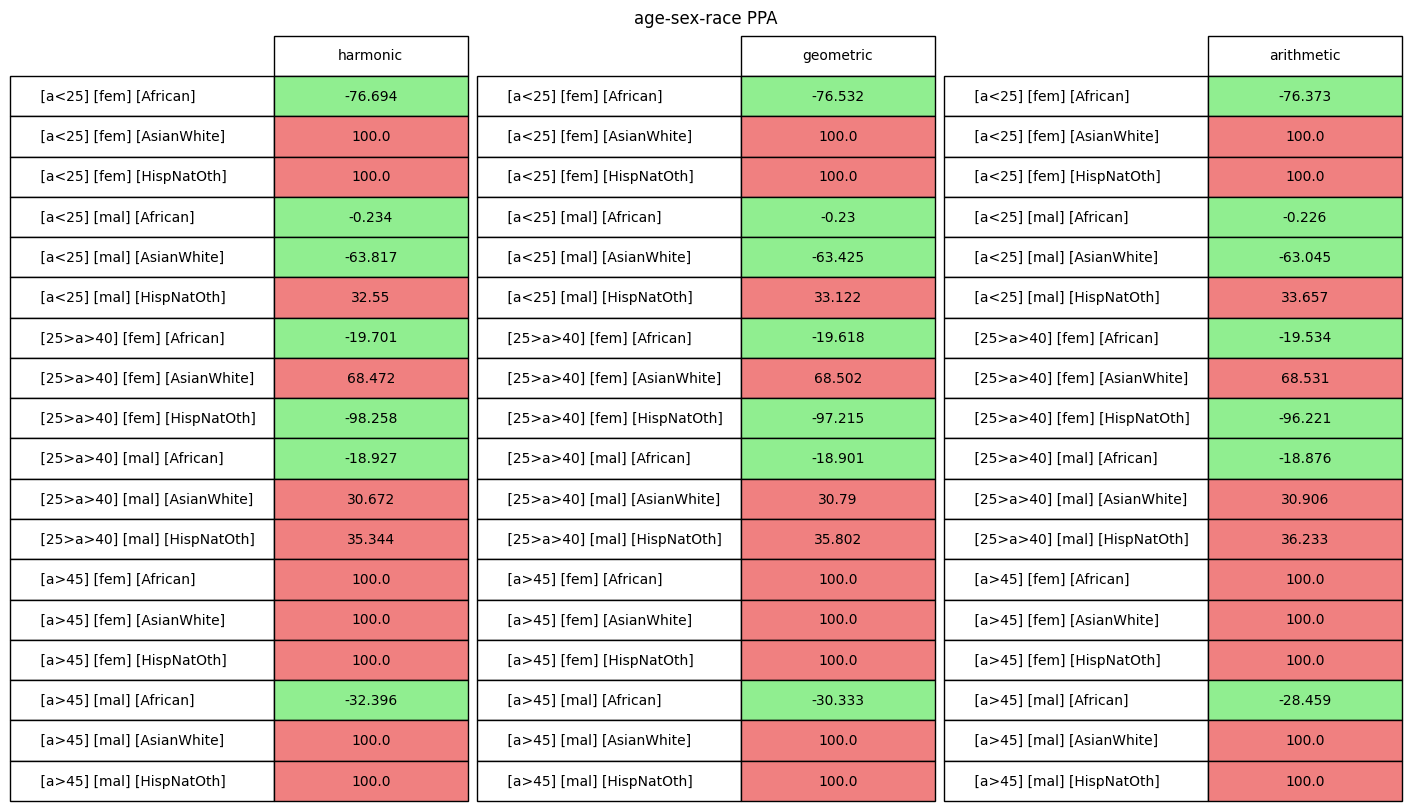

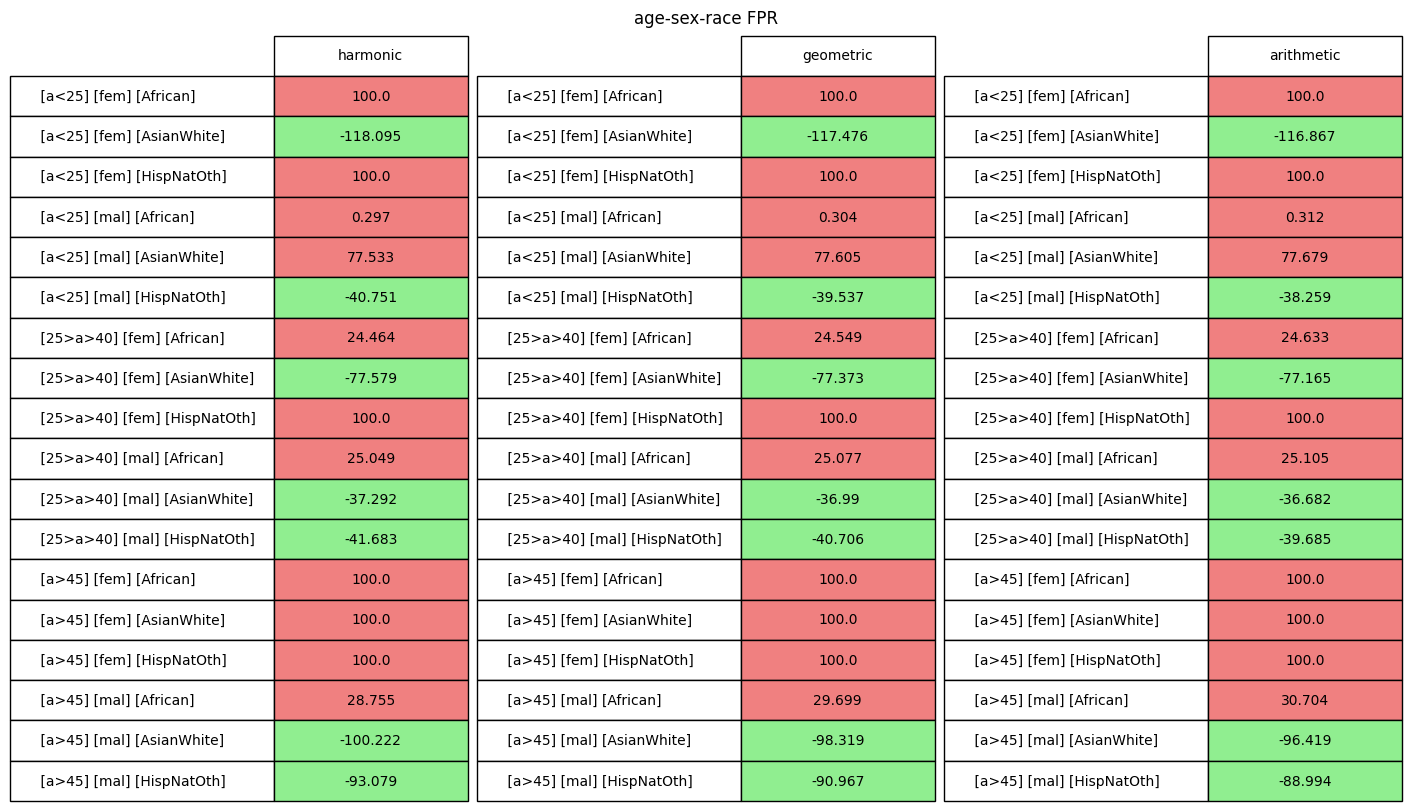

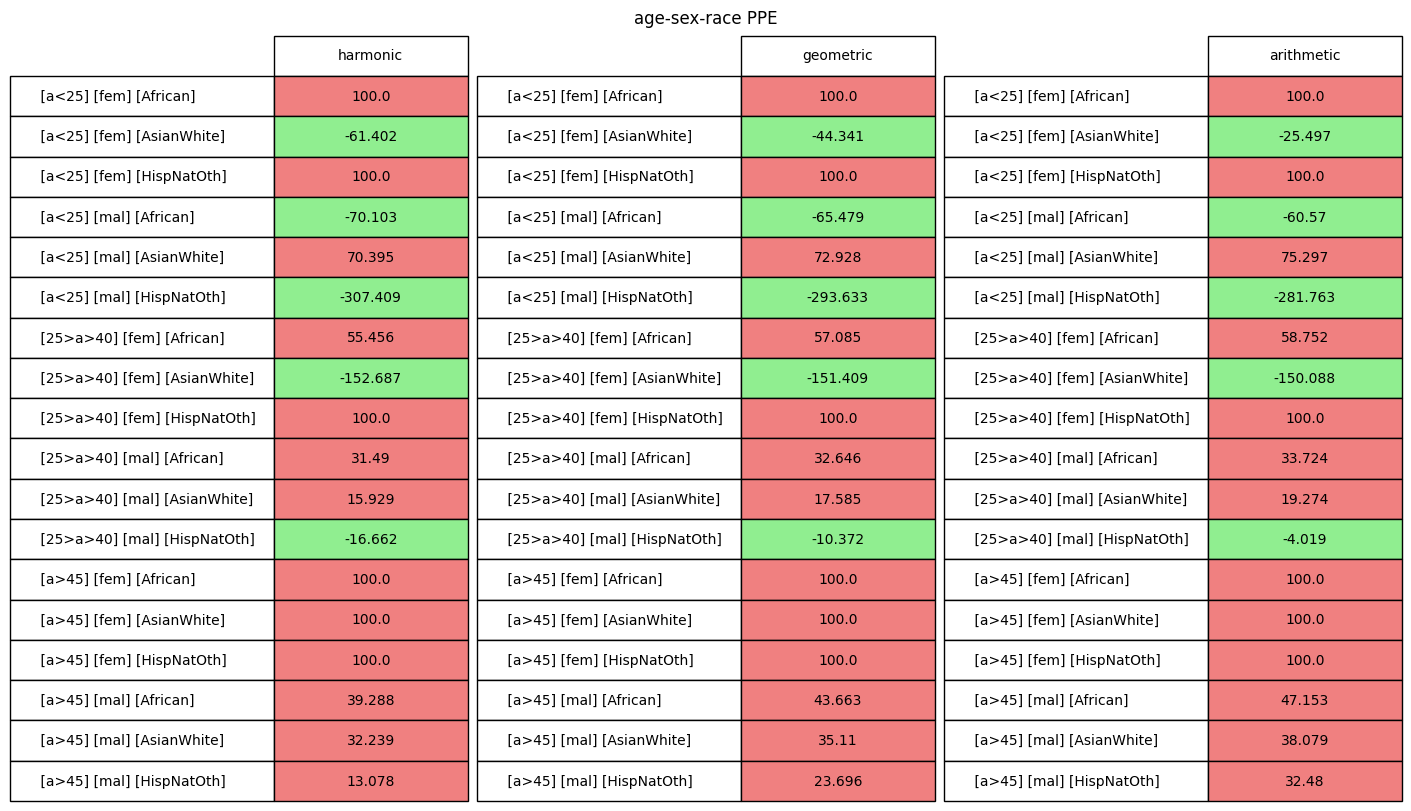

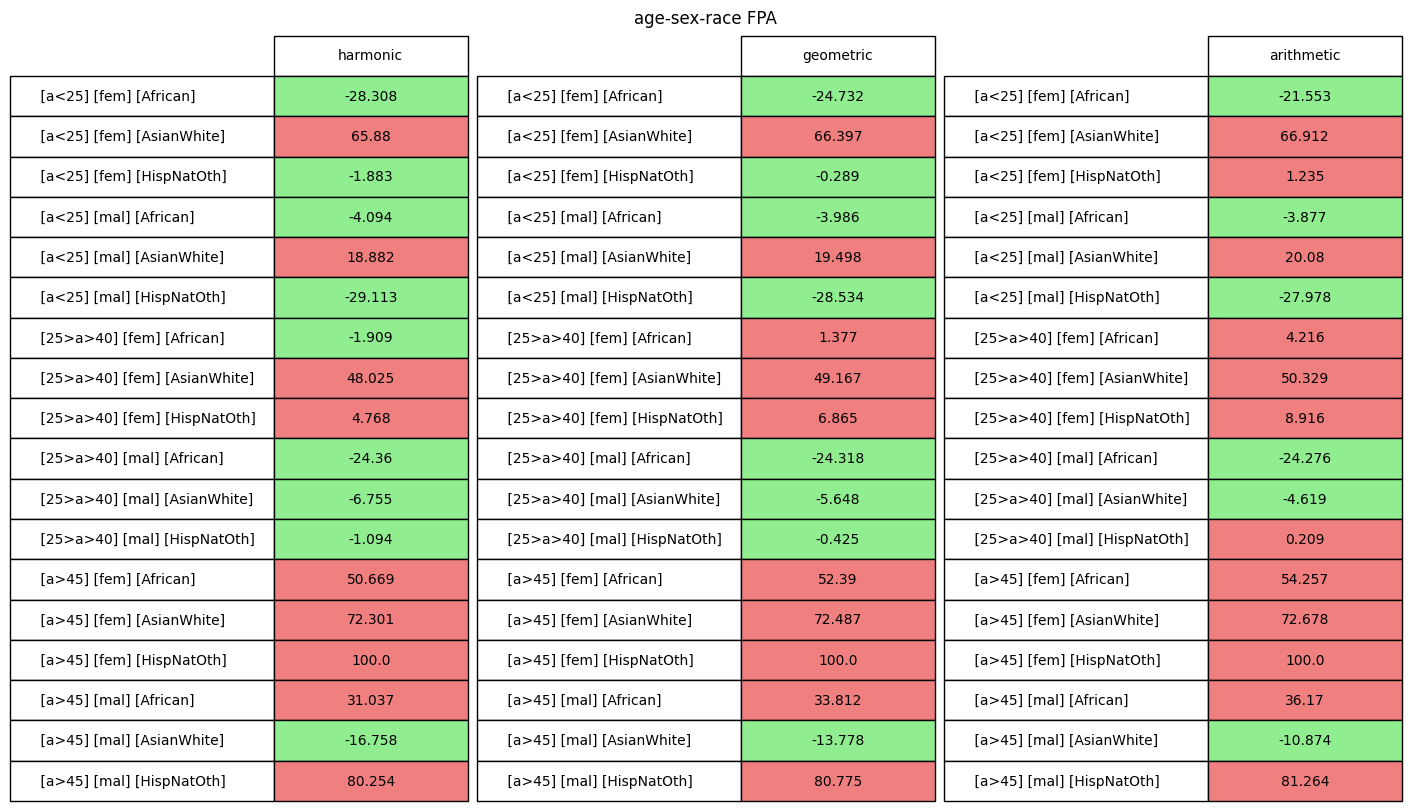

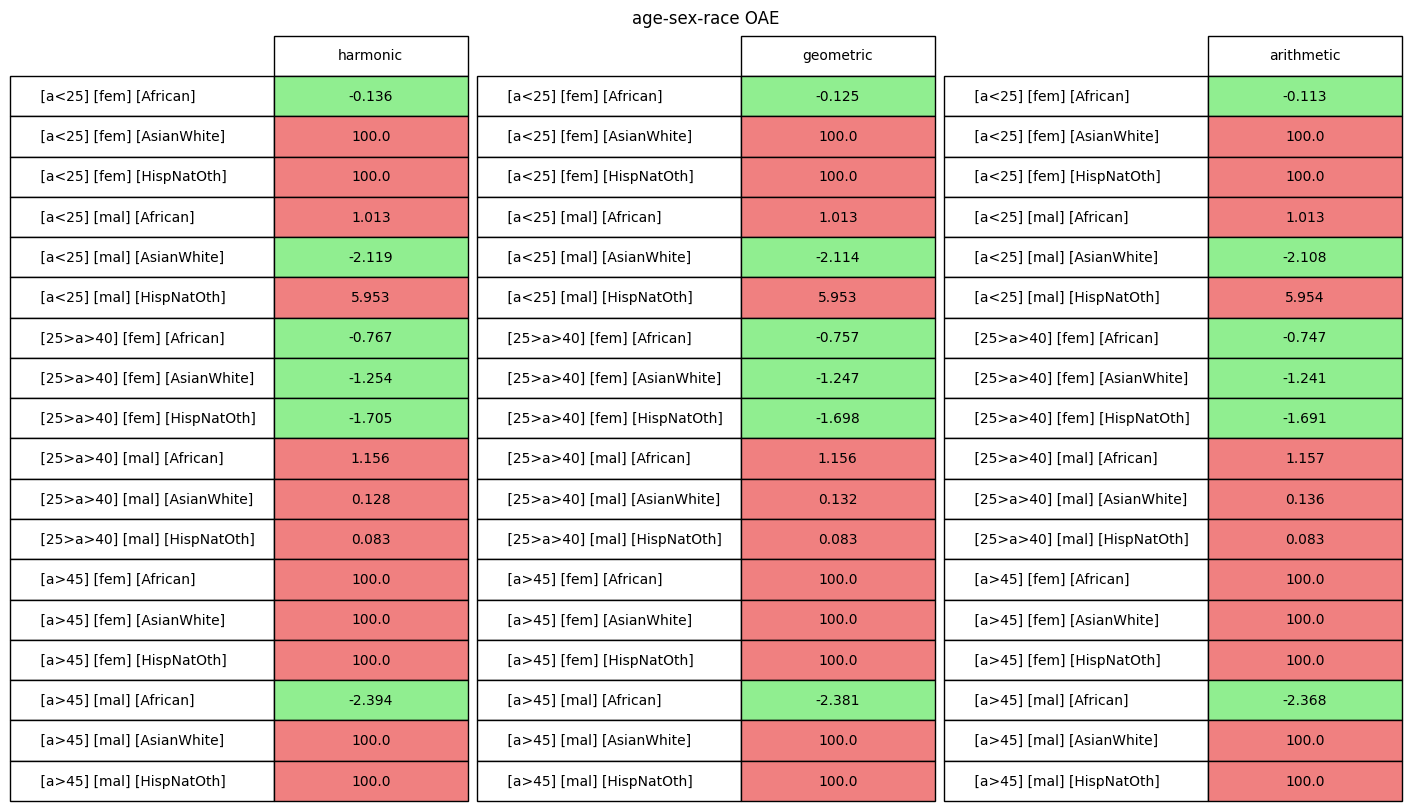

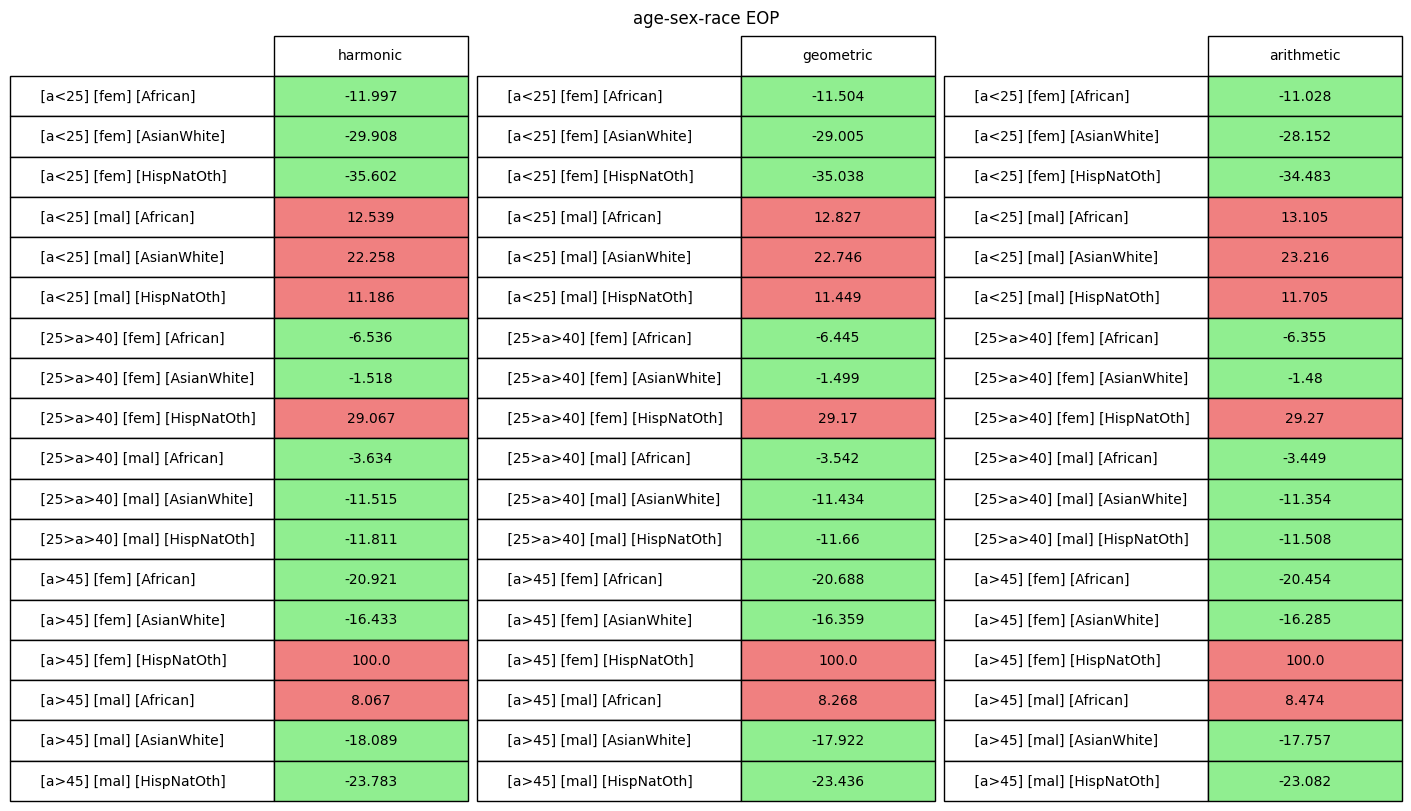

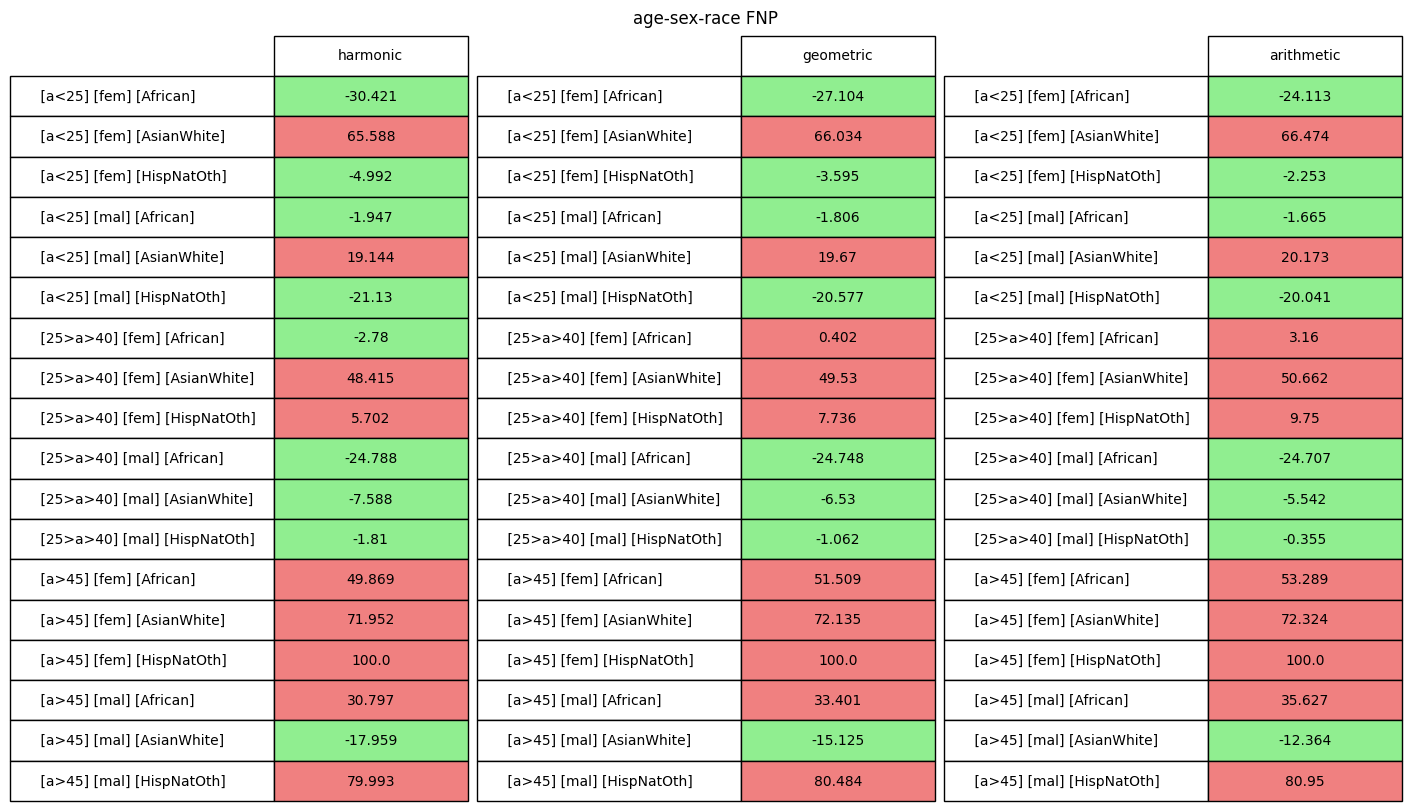

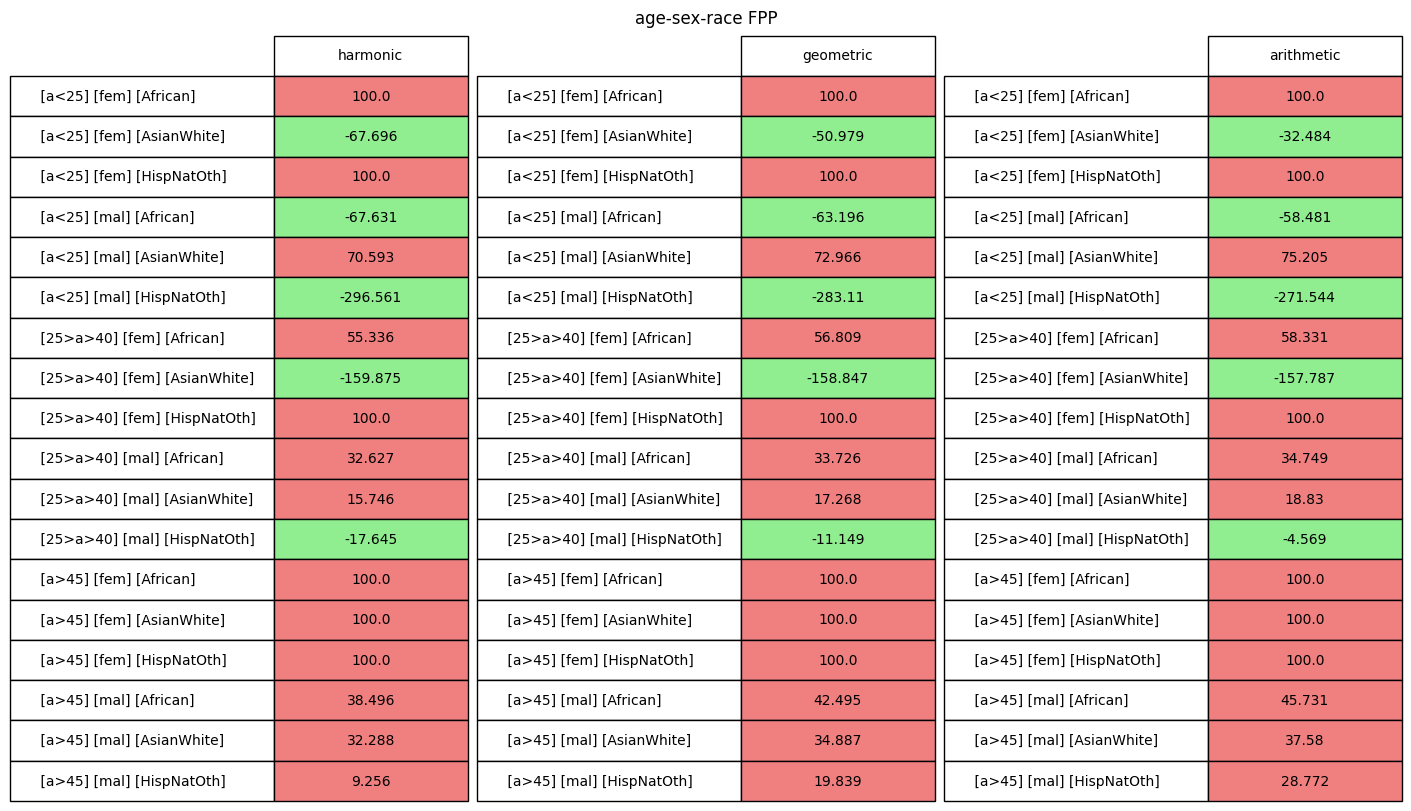

In [ ]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      #if len(s)==2:
        #print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      if len(s)==3:
        print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

In [ ]:
print('done')

done
